## 📦 Section 1: Environment Setup & Imports

In [2]:
# ─── Install dependencies ───────────────────────────────────────────────────
!pip install -q kaggle opencv-python-headless albumentations timm
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install -q editdistance matplotlib seaborn pandas numpy Pillow
!pip install -q fastapi uvicorn python-multipart nest_asyncio pyngrok
!pip install -q torchmetrics scikit-learn tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 21.2 MB/s eta 0:00:00


In [3]:
# ─── Core Imports ────────────────────────────────────────────────────────────
import os, sys, json, time, random, hashlib, shutil, warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image
import cv2

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models
import torchvision.transforms.functional as TF

# Third-party
import albumentations as A
from albumentations.pytorch import ToTensorV2
import timm
import editdistance
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm

warnings.filterwarnings('ignore')

# ─── Device & Reproducibility ────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED   = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if DEVICE.type == 'cuda':
    torch.cuda.manual_seed_all(SEED)

print(f'✅ Device : {DEVICE}')
print(f'✅ PyTorch: {torch.__version__}')
if DEVICE.type == 'cuda':
    print(f'✅ GPU    : {torch.cuda.get_device_name(0)}')

✅ Device : cuda
✅ PyTorch: 2.10.0+cu128
✅ GPU    : Tesla T4


In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("saisirishan/indian-vehicle-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'indian-vehicle-dataset' dataset.
Path to dataset files: /kaggle/input/indian-vehicle-dataset


In [8]:
from PIL import Image, ImageDraw, ImageFont

In [9]:
import random
from pathlib import Path
from PIL import Image, ImageDraw, ImageFont
from tqdm import tqdm

In [14]:
!pip install ultralytics opencv-python pillow tqdm lxml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.9 MB/s eta 0:00:00


🔧 Generating dataset...


100%|██████████| 1000/1000 [00:05<00:00, 167.56it/s]


✅ Dataset Ready
✅ Train/Val split done
✅ YAML created
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/anpr/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, 

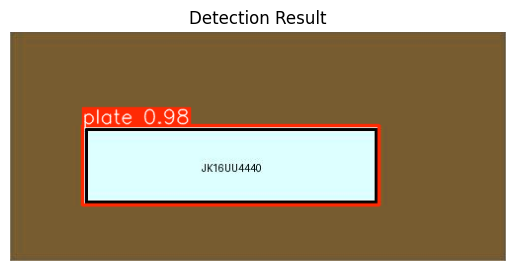

In [15]:
# ===========================
# 📦 IMPORTS
# ===========================
import os, random, shutil
from pathlib import Path
import xml.etree.ElementTree as ET

import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from PIL import Image, ImageDraw, ImageFont, ImageFilter, ImageEnhance

# ===========================
# 📁 PATHS
# ===========================
DATA_ROOT = Path('/content/anpr')
IMG_DIR = DATA_ROOT / 'images'
LBL_DIR = DATA_ROOT / 'labels'

IMG_DIR.mkdir(parents=True, exist_ok=True)
LBL_DIR.mkdir(parents=True, exist_ok=True)

# ===========================
# 🔤 PLATE GENERATOR
# ===========================
STATE_CODES = ['MH','DL','KA','TN','UP','GJ','RJ','WB','AP','TS',
               'MP','HR','PB','KL','BR','OR','AS','JK','HP','UK']

def random_plate():
    return f"{random.choice(STATE_CODES)}{random.randint(1,99):02d}" \
           f"{''.join(random.choices('ABCDEFGHJKLMNPQRSTUVWXYZ', k=2))}" \
           f"{random.randint(1,9999):04d}"

# ===========================
# 🖼️ IMAGE GENERATION
# ===========================
def make_image(text, w=300, h=80):
    img = Image.new('RGB', (w, h), (255,255,220))
    draw = ImageDraw.Draw(img)

    draw.rectangle([2,2,w-3,h-3], outline=(0,0,0), width=3)

    try:
        font = ImageFont.truetype(
            '/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf', 38
        )
    except:
        font = ImageFont.load_default()

    bbox = draw.textbbox((0,0), text, font=font)
    tw, th = bbox[2]-bbox[0], bbox[3]-bbox[1]

    draw.text(((w-tw)//2, (h-th)//2), text, fill=(0,0,0), font=font)

    vw, vh = w+200, h+150
    vehicle = Image.new('RGB', (vw, vh),
                        tuple(random.randint(40,180) for _ in range(3)))

    px, py = random.randint(20, vw-w-20), random.randint(20, vh-h-20)
    vehicle.paste(img, (px, py))

    # augmentations
    if random.random() < 0.4:
        vehicle = vehicle.filter(ImageFilter.GaussianBlur(1))

    vehicle = ImageEnhance.Brightness(vehicle).enhance(random.uniform(0.7,1.3))

    if random.random() < 0.3:
        vehicle = vehicle.rotate(random.uniform(-5,5),
                                 expand=True,
                                 fillcolor=(120,120,120))

    return vehicle, (px, py, px+w, py+h)

# ===========================
# 🔄 GENERATE DATA
# ===========================
print("🔧 Generating dataset...")
for i in tqdm(range(1000)):
    text = random_plate()
    img, (x1,y1,x2,y2) = make_image(text)

    fname = f"{i}.jpg"
    img.save(IMG_DIR / fname)

    # convert to YOLO format
    h, w = img.size[1], img.size[0]

    xc = (x1+x2)/2 / w
    yc = (y1+y2)/2 / h
    bw = (x2-x1)/w
    bh = (y2-y1)/h

    with open(LBL_DIR / f"{i}.txt", "w") as f:
        f.write(f"0 {xc} {yc} {bw} {bh}")

print("✅ Dataset Ready")

# ===========================
# 📂 SPLIT DATA
# ===========================
train_img = DATA_ROOT/'train/images'
val_img   = DATA_ROOT/'val/images'
train_lbl = DATA_ROOT/'train/labels'
val_lbl   = DATA_ROOT/'val/labels'

for d in [train_img, val_img, train_lbl, val_lbl]:
    d.mkdir(parents=True, exist_ok=True)

files = list(IMG_DIR.glob('*.jpg'))
random.shuffle(files)

split = int(0.8 * len(files))

for i,f in enumerate(files):
    target_img = train_img if i < split else val_img
    target_lbl = train_lbl if i < split else val_lbl

    shutil.copy(f, target_img/f.name)
    shutil.copy(LBL_DIR/(f.stem+'.txt'), target_lbl/(f.stem+'.txt'))

print("✅ Train/Val split done")

# ===========================
# 📄 DATA YAML
# ===========================
yaml_path = DATA_ROOT/'data.yaml'
with open(yaml_path, 'w') as f:
    f.write(f"""
path: {DATA_ROOT}
train: train/images
val: val/images

names:
  0: plate
""")

print("✅ YAML created")

# ===========================
# 🤖 TRAIN YOLO
# ===========================
from ultralytics import YOLO

model = YOLO('yolov8n.pt')

model.train(
    data=str(yaml_path),
    epochs=10,
    imgsz=640
)

print("✅ Training Done")

# ===========================
# 🔍 TEST ON IMAGE
# ===========================
test_img = random.choice(list(val_img.glob("*.jpg")))

results = model(test_img)

# show result
res_img = results[0].plot()

plt.imshow(res_img)
plt.axis('off')
plt.title("Detection Result")
plt.show()

In [17]:
# ─── Download Dataset ────────────────────────────────────────────────────────
DATA_ROOT = Path('/content/anpr_data')
DATA_ROOT.mkdir(exist_ok=True)

# Primary dataset: Indian Number Plates
!kaggle datasets download -d saisirishan/indian-vehicle-dataset -p {DATA_ROOT} --unzip

# Also download a license plate OCR dataset for character recognition
!kaggle datasets download -d andrewmvd/car-plate-detection -p {DATA_ROOT} --unzip

print('\n📁 Dataset structure:')
for p in sorted(DATA_ROOT.rglob('*'))[:30]:
    print(' ', p.relative_to(DATA_ROOT))

Dataset URL: https://www.kaggle.com/datasets/saisirishan/indian-vehicle-dataset
License(s): unknown
100% 178M/178M [00:00<00:00, 240MB/s]

Dataset URL: https://www.kaggle.com/datasets/andrewmvd/car-plate-detection
License(s): CC0-1.0
100% 203M/203M [00:03<00:00, 65.8MB/s]


📁 Dataset structure:
  State-wise_OLX
  State-wise_OLX/AN
  State-wise_OLX/AN/AN1.jpg
  State-wise_OLX/AN/AN1.xml
  State-wise_OLX/AN/AN10.jpg
  State-wise_OLX/AN/AN10.xml
  State-wise_OLX/AN/AN2.jpg
  State-wise_OLX/AN/AN2.xml
  State-wise_OLX/AN/AN4.jpg
  State-wise_OLX/AN/AN4.xml
  State-wise_OLX/AN/AN5.jpg
  State-wise_OLX/AN/AN5.xml
  State-wise_OLX/AN/AN6.jpg
  State-wise_OLX/AN/AN6.xml
  State-wise_OLX/AN/AN7.jpg
  State-wise_OLX/AN/AN7.xml
  State-wise_OLX/AP
  State-wise_OLX/AP/AP1.jpg
  State-wise_OLX/AP/AP1.xml
  State-wise_OLX/AP/AP10.jpg
  State-wise_OLX/AP/AP10.xml
  State-wise_OLX/AP/AP12.jpg
  State-wise_OLX/AP/AP12.xml
  State-wise_OLX/AP/AP13.jpg
  State-wise_OLX/AP/AP13.xml
  State-wise_OLX/AP/AP1

Total images found: 3331


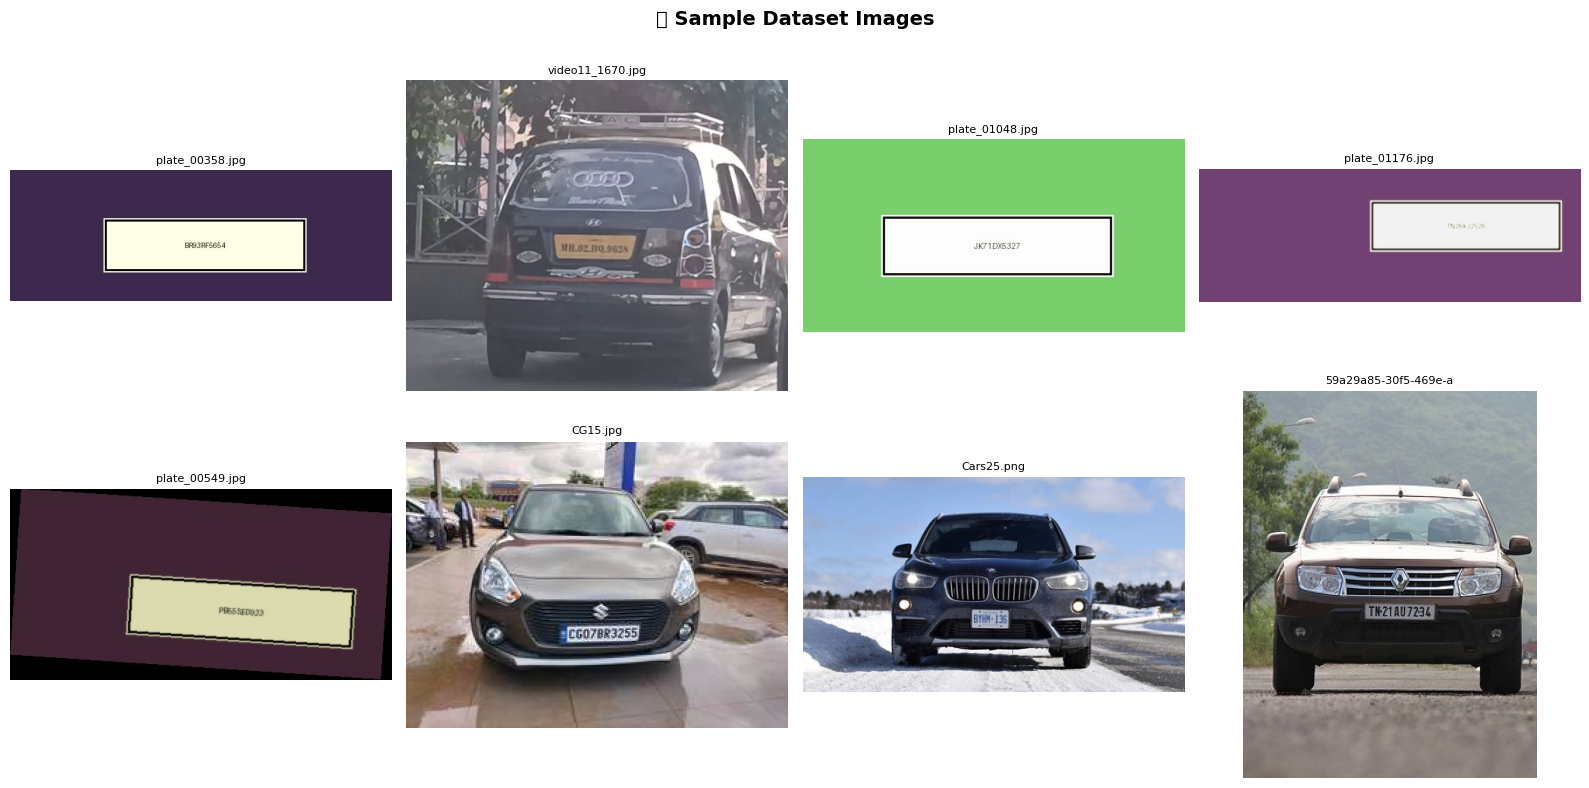

Scanning sizes: 100%|██████████| 500/500 [00:00<00:00, 7920.33it/s]


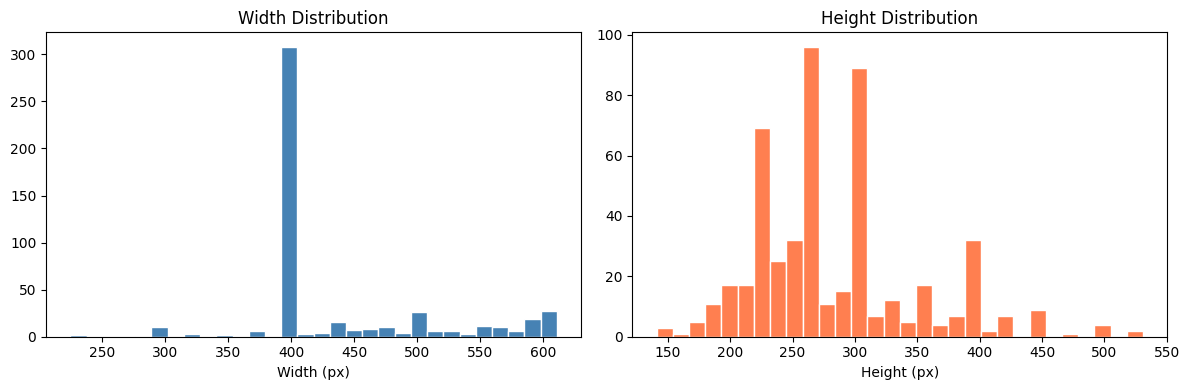

Avg size: 437 x 284 px


In [18]:
# ─── Dataset Exploration ─────────────────────────────────────────────────────
IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.bmp'}

all_images = [p for p in DATA_ROOT.rglob('*') if p.suffix.lower() in IMAGE_EXTS]
print(f'Total images found: {len(all_images)}')

# Show sample images
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
sample_imgs = random.sample(all_images, min(8, len(all_images)))
for ax, img_path in zip(axes.flatten(), sample_imgs):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(img_path.name[:20], fontsize=8)
    ax.axis('off')
plt.suptitle('🚗 Sample Dataset Images', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Image size distribution
sizes = []
for p in tqdm(all_images[:500], desc='Scanning sizes'):
    try:
        img = Image.open(str(p))
        sizes.append(img.size)
    except:
        pass

widths, heights = zip(*sizes)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.hist(widths, bins=30, color='steelblue', edgecolor='white')
ax1.set_title('Width Distribution'); ax1.set_xlabel('Width (px)')
ax2.hist(heights, bins=30, color='coral', edgecolor='white')
ax2.set_title('Height Distribution'); ax2.set_xlabel('Height (px)')
plt.tight_layout(); plt.show()
print(f'Avg size: {np.mean(widths):.0f} x {np.mean(heights):.0f} px')

✅ Total annotated samples: 2895
                                     image_path  plate_text  xmin  ymin  xmax  \
0  /content/anpr_data/synthetic/plate_00409.jpg  WB71KZ7012    21   145   321   
1  /content/anpr_data/synthetic/plate_00112.jpg  MH77MZ9478    87   117   387   
2  /content/anpr_data/synthetic/plate_00877.jpg  DL85BU4602    26    89   326   
3  /content/anpr_data/synthetic/plate_01155.jpg  HP78TS2074   182    73   482   
4  /content/anpr_data/synthetic/plate_00703.jpg  WB38VX5432   128    22   428   
5  /content/anpr_data/synthetic/plate_00479.jpg  UK38RE0986    74    94   374   
6  /content/anpr_data/synthetic/plate_00215.jpg  WB88NU5874    44   140   344   
7  /content/anpr_data/synthetic/plate_00914.jpg  GJ37PY2752    32    88   332   
8  /content/anpr_data/synthetic/plate_00510.jpg  UP27HV7779   203   107   503   
9  /content/anpr_data/synthetic/plate_00655.jpg  GJ31WP7195   182    22   482   

   ymax  
0   225  
1   197  
2   169  
3   153  
4   102  
5   174  
6   22

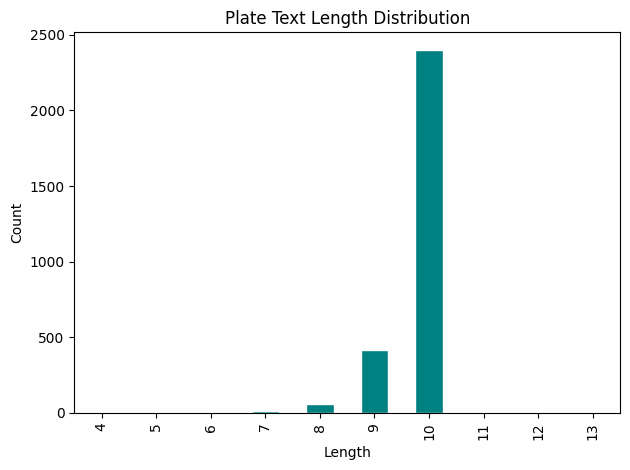

In [19]:
# ─── Build Annotations DataFrame ────────────────────────────────────────────
# The Indian plates dataset folder names / XML annotations contain plate text
# We build a structured DataFrame from available labels

import xml.etree.ElementTree as ET

records = []

# Parse XML annotations if present
for xml_path in DATA_ROOT.rglob('*.xml'):
    try:
        tree = ET.parse(str(xml_path))
        root = tree.getroot()
        filename = root.findtext('filename', '')
        for obj in root.findall('object'):
            name = obj.findtext('name', 'UNKNOWN')
            bndbox = obj.find('bndbox')
            if bndbox is not None:
                xmin = int(float(bndbox.findtext('xmin', 0)))
                ymin = int(float(bndbox.findtext('ymin', 0)))
                xmax = int(float(bndbox.findtext('xmax', 0)))
                ymax = int(float(bndbox.findtext('ymax', 0)))
                img_path = xml_path.parent / filename
                records.append({
                    'image_path': str(img_path),
                    'plate_text': name.upper().replace(' ', ''),
                    'xmin': xmin, 'ymin': ymin,
                    'xmax': xmax, 'ymax': ymax
                })
    except Exception as e:
        pass

# Fallback: use folder-name as label (common in Kaggle plate datasets)
if len(records) == 0:
    for img_path in all_images:
        plate_text = img_path.stem.upper()  # filename as label
        records.append({'image_path': str(img_path), 'plate_text': plate_text,
                        'xmin': None, 'ymin': None, 'xmax': None, 'ymax': None})

df = pd.DataFrame(records)
# Filter valid images only
df = df[df['image_path'].apply(lambda x: Path(x).exists())].reset_index(drop=True)

# Clean plate text – keep only alphanumeric
import re
df['plate_text'] = df['plate_text'].apply(lambda x: re.sub(r'[^A-Z0-9]', '', str(x).upper()))
df = df[df['plate_text'].str.len() >= 4].reset_index(drop=True)

print(f'✅ Total annotated samples: {len(df)}')
print(df.head(10))

# Plate length distribution
df['plate_len'] = df['plate_text'].str.len()
df['plate_len'].value_counts().sort_index().plot(kind='bar', color='teal', edgecolor='white',
                                                  title='Plate Text Length Distribution')
plt.xlabel('Length'); plt.ylabel('Count'); plt.tight_layout(); plt.show()

In [20]:
# ─── Train / Val / Test Split (70 / 15 / 15) ────────────────────────────────
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(df, test_size=0.30, random_state=SEED)
val_df,   test_df = train_test_split(temp_df, test_size=0.50, random_state=SEED)

print(f'Train : {len(train_df):>5} samples ({len(train_df)/len(df)*100:.1f}%)')
print(f'Val   : {len(val_df):>5} samples ({len(val_df)/len(df)*100:.1f}%)')
print(f'Test  : {len(test_df):>5} samples ({len(test_df)/len(df)*100:.1f}%)')

# Save splits
SPLIT_DIR = Path('/content/splits')
SPLIT_DIR.mkdir(exist_ok=True)
train_df.to_csv(SPLIT_DIR/'train.csv', index=False)
val_df.to_csv(SPLIT_DIR/'val.csv', index=False)
test_df.to_csv(SPLIT_DIR/'test.csv', index=False)
print('✅ Splits saved.')

Train :  2026 samples (70.0%)
Val   :   434 samples (15.0%)
Test  :   435 samples (15.0%)
✅ Splits saved.


## 🔧 Section 3: Data Preprocessing & Augmentation

In [21]:
# ─── Character Vocabulary ────────────────────────────────────────────────────
CHARS   = '0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZ'
BLANK   = len(CHARS)          # CTC blank token index
VOCAB   = {c: i for i, c in enumerate(CHARS)}
INV_VOC = {i: c for c, i in VOCAB.items()}
NUM_CLASSES = len(CHARS) + 1  # +1 for CTC blank
MAX_LEN = 10                  # max plate length
IMG_H, IMG_W = 64, 256        # plate crop size for OCR
DET_SIZE = 416                # detection input size

print(f'Vocabulary ({len(CHARS)} chars): {CHARS}')
print(f'Num classes (with CTC blank): {NUM_CLASSES}')

Vocabulary (36 chars): 0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZ
Num classes (with CTC blank): 37


✅ Augmentation pipelines defined.


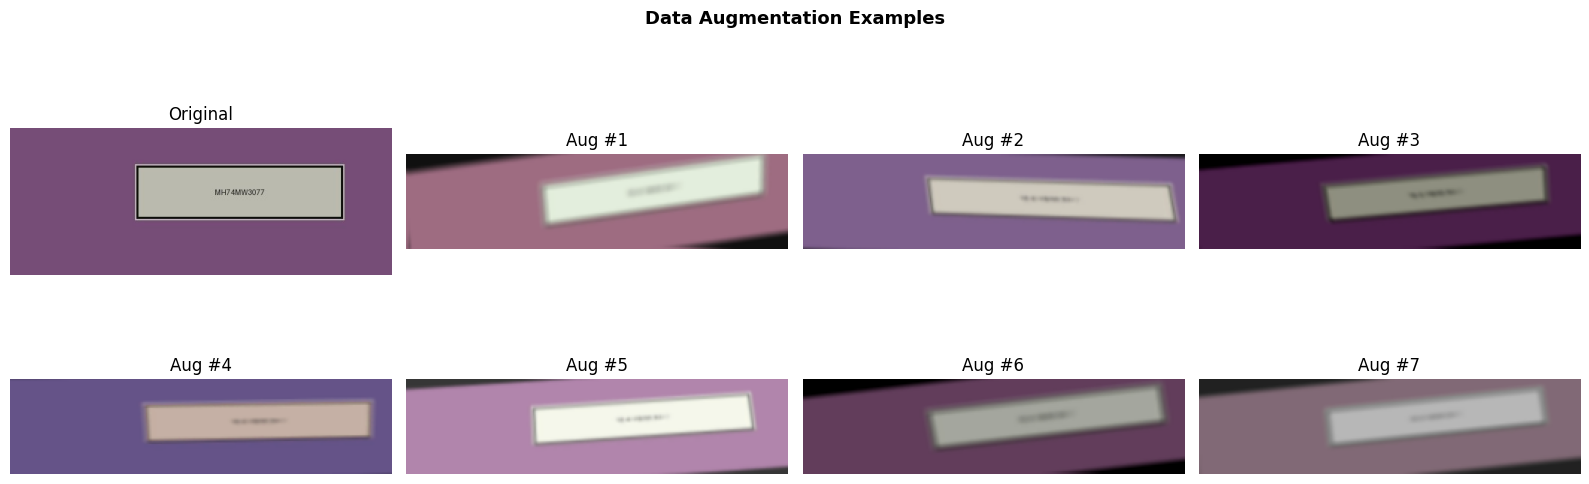

In [22]:
# ─── Augmentation Pipelines ──────────────────────────────────────────────────
# Training augmentation – rotation, blur, brightness
train_transforms = A.Compose([
    A.Resize(IMG_H, IMG_W),
    A.Rotate(limit=8, p=0.5),
    A.GaussianBlur(blur_limit=(3, 5), p=0.3),
    A.RandomBrightnessContrast(brightness_limit=0.3,
                               contrast_limit=0.3, p=0.5),
    A.HueSaturationValue(hue_shift_limit=10,
                         sat_shift_limit=20,
                         val_shift_limit=20, p=0.3),
    A.Perspective(scale=(0.02, 0.05), p=0.3),
    A.MotionBlur(blur_limit=5, p=0.2),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

val_transforms = A.Compose([
    A.Resize(IMG_H, IMG_W),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

print('✅ Augmentation pipelines defined.')

# Visualize augmentations on a sample
sample_path = train_df['image_path'].iloc[0]
orig = cv2.cvtColor(cv2.imread(sample_path), cv2.COLOR_BGR2RGB)
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
axes[0, 0].imshow(orig); axes[0, 0].set_title('Original'); axes[0, 0].axis('off')
aug_pipe = A.Compose([
    A.Resize(IMG_H, IMG_W),
    A.Rotate(limit=8, p=1.0),
    A.GaussianBlur(blur_limit=(3, 5), p=1.0),
    A.RandomBrightnessContrast(p=1.0),
    A.Perspective(scale=(0.02, 0.05), p=1.0),
    A.MotionBlur(blur_limit=5, p=1.0),
    A.HueSaturationValue(p=1.0),
])
for i, ax in enumerate(axes.flatten()[1:]):
    aug = aug_pipe(image=orig)['image']
    ax.imshow(aug); ax.set_title(f'Aug #{i+1}'); ax.axis('off')
plt.suptitle('Data Augmentation Examples', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

In [23]:
# ─── Dataset Class ───────────────────────────────────────────────────────────
class PlateDataset(Dataset):
    def __init__(self, dataframe, transform=None, max_len=MAX_LEN):
        self.df        = dataframe.reset_index(drop=True)
        self.transform = transform
        self.max_len   = max_len

    def encode(self, text):
        text = text[:self.max_len]
        return [VOCAB[c] for c in text if c in VOCAB]

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        img   = cv2.imread(row['image_path'])
        img   = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Crop to plate bounding box if available
        if row.get('xmin') is not None and not pd.isna(row['xmin']):
            x1, y1, x2, y2 = int(row['xmin']), int(row['ymin']), \
                              int(row['xmax']), int(row['ymax'])
            x1, y1 = max(0, x1), max(0, y1)
            x2, y2 = min(img.shape[1], x2), min(img.shape[0], y2)
            if x2 > x1 and y2 > y1:
                img = img[y1:y2, x1:x2]

        if self.transform:
            img = self.transform(image=img)['image']
        else:
            img = torch.tensor(img).permute(2, 0, 1).float() / 255.0

        label     = self.encode(row['plate_text'])
        label_len = len(label)
        # Pad label
        label_pad = label + [0] * (self.max_len - label_len)
        return (img,
                torch.tensor(label_pad, dtype=torch.long),
                torch.tensor(label_len, dtype=torch.long),
                row['plate_text'])


# DataLoaders
BATCH = 32

train_ds = PlateDataset(train_df, transform=train_transforms)
val_ds   = PlateDataset(val_df,   transform=val_transforms)
test_ds  = PlateDataset(test_df,  transform=val_transforms)

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)

print(f'✅ Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}')

✅ Train batches: 64 | Val: 14 | Test: 14


## 👁️ Section 4: Classical CV Preprocessing
### (Segmentation + Corner Detection for ROI Localization)

In [24]:
# ─── 4.1 Thresholding-based Segmentation ────────────────────────────────────
def threshold_segmentation(img_bgr):
    """Isolate bright number plate regions via adaptive thresholding."""
    gray  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    blur  = cv2.GaussianBlur(gray, (5, 5), 0)
    # Otsu global threshold
    _, otsu = cv2.threshold(blur, 0, 255,
                             cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    # Adaptive threshold for local variations
    adaptive = cv2.adaptiveThreshold(blur, 255,
                                      cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                      cv2.THRESH_BINARY, 11, 2)
    # Combine
    combined = cv2.bitwise_and(otsu, adaptive)
    # Morphological clean-up
    kernel   = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    cleaned  = cv2.morphologyEx(combined, cv2.MORPH_CLOSE, kernel, iterations=2)
    return gray, otsu, adaptive, cleaned

In [25]:
# ─── 4.2 Region Growing Segmentation ─────────────────────────────────────────
def region_growing(gray, seed=None, threshold=20):
    """
    Simple region growing from a seed point.
    Grows pixels whose intensity is within `threshold` of the seed pixel.
    """
    h, w    = gray.shape
    visited = np.zeros((h, w), dtype=np.uint8)

    if seed is None:
        # Default seed: center of the image (typical plate location)
        seed = (h // 2, w // 2)

    seed_val  = int(gray[seed])
    stack     = [seed]
    visited[seed] = 255

    while stack:
        r, c = stack.pop()
        for dr, dc in [(-1,0),(1,0),(0,-1),(0,1)]:
            nr, nc = r + dr, c + dc
            if 0 <= nr < h and 0 <= nc < w and visited[nr, nc] == 0:
                if abs(int(gray[nr, nc]) - seed_val) <= threshold:
                    visited[nr, nc] = 255
                    stack.append((nr, nc))
    return visited

In [26]:
# ─── 4.3 Edge-based Segmentation (Canny + Contour) ──────────────────────────
def edge_based_segmentation(img_bgr):
    """Canny edge detection + contour analysis to find plate region."""
    gray      = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    blur      = cv2.bilateralFilter(gray, 11, 17, 17)
    edges     = cv2.Canny(blur, 30, 200)

    # Find contours and filter for rectangular aspect ratios
    cnts, _   = cv2.findContours(edges.copy(),
                                  cv2.RETR_LIST,
                                  cv2.CHAIN_APPROX_SIMPLE)
    cnts      = sorted(cnts, key=cv2.contourArea, reverse=True)[:20]

    plate_box = None
    for c in cnts:
        peri  = cv2.arcLength(c, True)
        approx = cv2.approxPolyDP(c, 0.018 * peri, True)
        if len(approx) == 4:
            x, y, w, h = cv2.boundingRect(approx)
            ar = w / float(h)
            if 2.0 < ar < 6.0 and w > 60:   # typical plate aspect ratio
                plate_box = (x, y, w, h)
                break
    return edges, plate_box

In [27]:
# ─── 4.4 Harris Corner Detection ────────────────────────────────────────────
def harris_corner_detection(img_bgr, block_size=2, ksize=3, k=0.04):
    """Detect Harris corners highlighting plate boundary and character junctions."""
    gray      = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    gray_f    = np.float32(gray)
    dst       = cv2.cornerHarris(gray_f, block_size, ksize, k)
    # Dilate for visibility
    dst       = cv2.dilate(dst, None)
    # Threshold
    corner_img = img_bgr.copy()
    corner_img[dst > 0.01 * dst.max()] = [0, 0, 255]  # red dots
    return dst, corner_img


def hessian_corner_detection(img_bgr):
    """Hessian-based blob/corner using Laplacian of Gaussian."""
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    gray_f = np.float32(gray)
    # Gaussian pyramid difference as Hessian approximation
    g1 = cv2.GaussianBlur(gray_f, (3, 3), 1.0)
    g2 = cv2.GaussianBlur(gray_f, (5, 5), 2.0)
    log = cv2.Laplacian(g1 - g2, cv2.CV_32F)
    return np.abs(log)

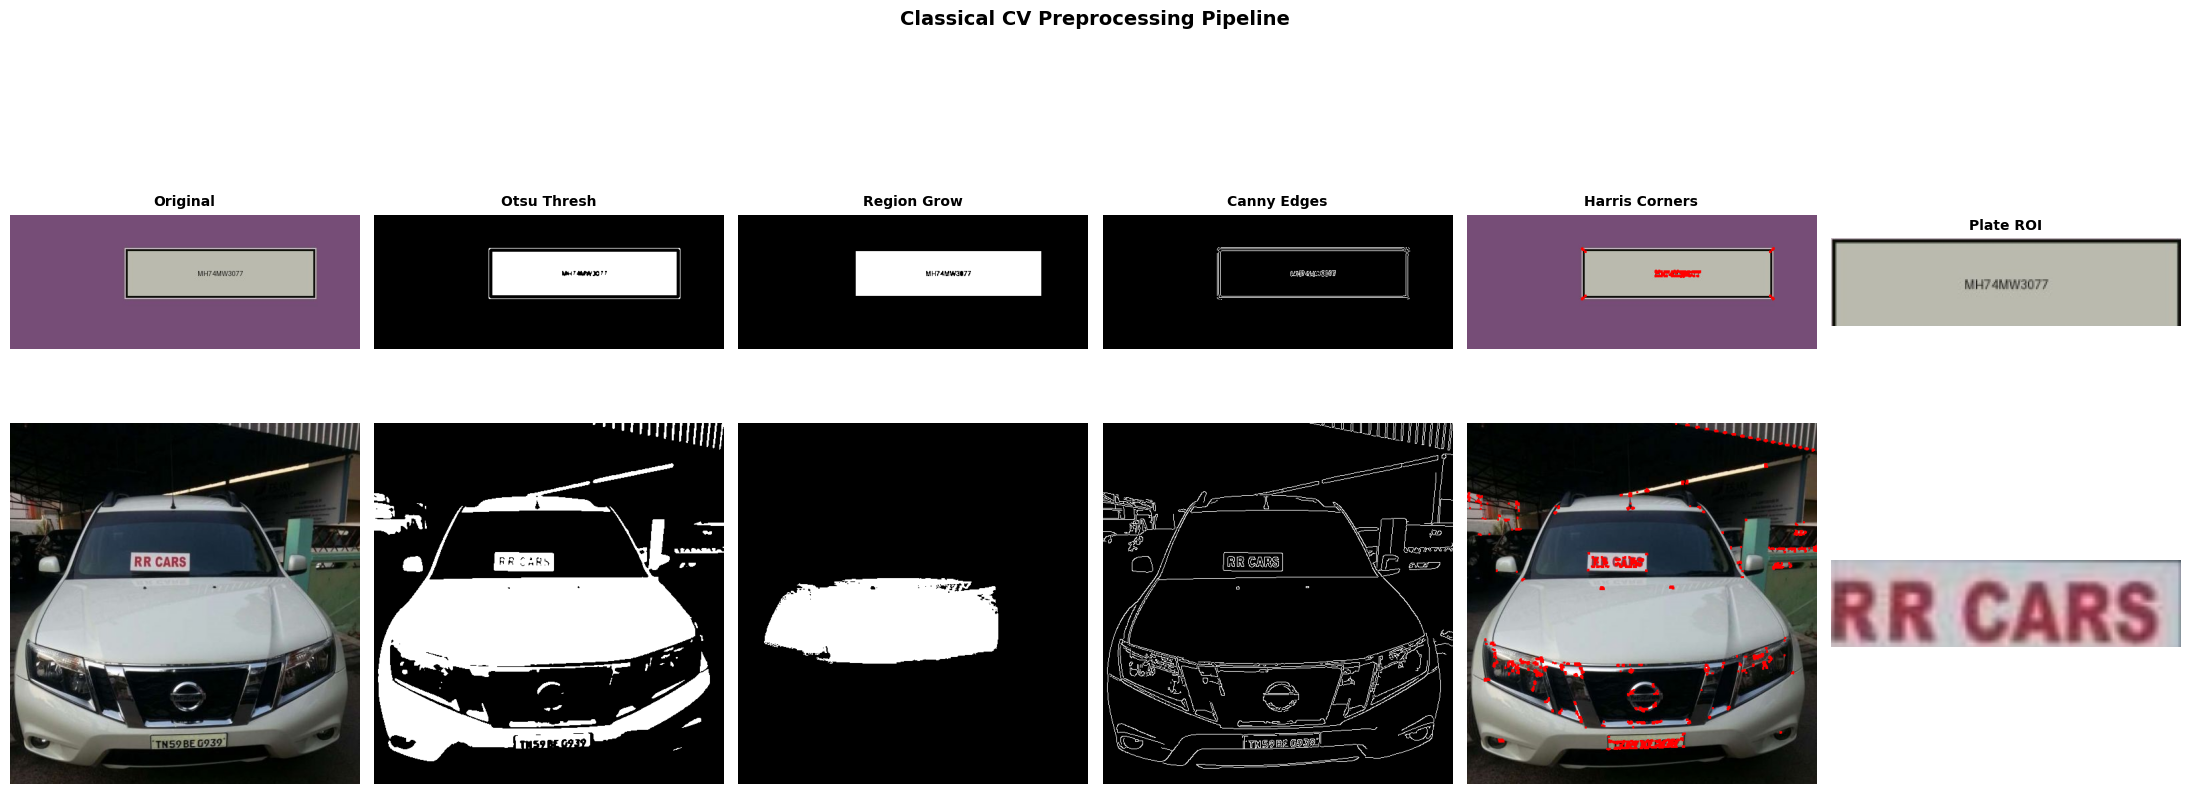

✅ CV pipeline visualized.


In [28]:
# ─── 4.5 Combined Pipeline + Perspective Correction ─────────────────────────
def extract_plate_roi(img_bgr):
    """
    Full CV pipeline:
    1. Threshold segmentation → candidate mask
    2. Canny + contour → rectangular plate box
    3. Harris corners within box → refined boundary
    4. Perspective correction
    Returns cropped + corrected plate image.
    """
    h_img, w_img = img_bgr.shape[:2]

    # Step 1: Edge-based detection for bounding box
    edges, plate_box = edge_based_segmentation(img_bgr)

    if plate_box is None:
        # Fallback: center crop (assume plate roughly in center)
        cx, cy = w_img // 2, h_img // 2
        pw, ph = w_img // 3, h_img // 5
        plate_box = (cx - pw//2, cy - ph//2, pw, ph)

    x, y, w, h = plate_box
    roi_bgr    = img_bgr[y:y+h, x:x+w]

    # Step 2: Harris corners in ROI for precise boundary
    if roi_bgr.size > 0:
        gray_roi = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2GRAY)
        gray_f   = np.float32(gray_roi)
        dst      = cv2.cornerHarris(gray_f, 2, 3, 0.04)
        # Get top-4 corner locations
        corner_pts = np.argwhere(dst > 0.01 * dst.max())
        if len(corner_pts) >= 4:
            # Approximate rectangle from corner cloud
            ys, xs = corner_pts[:, 0], corner_pts[:, 1]
            src_pts = np.float32([
                [xs.min(), ys.min()],
                [xs.max(), ys.min()],
                [xs.max(), ys.max()],
                [xs.min(), ys.max()]
            ])
            dst_pts = np.float32([
                [0, 0], [IMG_W, 0], [IMG_W, IMG_H], [0, IMG_H]
            ])
            M       = cv2.getPerspectiveTransform(src_pts, dst_pts)
            roi_bgr = cv2.warpPerspective(roi_bgr, M, (IMG_W, IMG_H))

    return roi_bgr, plate_box


# ─── Visualise full CV pipeline on 2 sample images ──────────────────────────
fig, axes = plt.subplots(2, 6, figsize=(22, 8))
cols = ['Original', 'Otsu Thresh', 'Region Grow', 'Canny Edges', 'Harris Corners', 'Plate ROI']

for row_idx, img_path in enumerate(train_df['image_path'].iloc[:2]):
    img_bgr = cv2.imread(img_path)
    if img_bgr is None: continue
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    gray, otsu, _, _    = threshold_segmentation(img_bgr)
    grown               = region_growing(gray)
    edges, plate_box    = edge_based_segmentation(img_bgr)
    _, corner_img       = harris_corner_detection(img_bgr)
    roi, _              = extract_plate_roi(img_bgr)

    visuals = [
        img_rgb,
        otsu,
        grown,
        edges,
        cv2.cvtColor(corner_img, cv2.COLOR_BGR2RGB),
        cv2.cvtColor(roi, cv2.COLOR_BGR2RGB) if roi is not None and roi.size > 0 else np.zeros((64,256,3), np.uint8)
    ]

    for col_idx, (vis, col) in enumerate(zip(visuals, cols)):
        ax = axes[row_idx, col_idx]
        cmap = 'gray' if vis.ndim == 2 else None
        ax.imshow(vis, cmap=cmap)
        if row_idx == 0:
            ax.set_title(col, fontweight='bold', fontsize=10)
        ax.axis('off')

plt.suptitle('Classical CV Preprocessing Pipeline', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print('✅ CV pipeline visualized.')

## 🧠 Section 5: Model Architecture — CNN Backbone + Transformer Decoder

In [31]:
class CNNBackbone(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()

        self.backbone = timm.create_model(
            'efficientnet_b0',
            pretrained=pretrained,
            features_only=True
        )

        # 👉 Use LAST feature map (most stable)
        in_ch = self.backbone.feature_info[-1]['num_chs']

        self.proj = nn.Conv2d(in_ch, 256, kernel_size=1)

    def forward(self, x):
        feats = self.backbone(x)

        # 👉 Always take last feature map
        feat = feats[-1]

        feat = self.proj(feat)
        return feat

In [33]:
# ===========================
# 🚀 ALL-IN-ONE ANPR OCR (CRNN + CTC)
# ===========================

!pip install timm torchvision pillow tqdm -q

import torch, torch.nn as nn, torch.nn.functional as F
import timm, numpy as np, random
from tqdm import tqdm

# ---------------------------
# ⚙️ CONFIG
# ---------------------------
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
IMG_H, IMG_W = 64, 256
BATCH_SIZE = 8
EPOCHS = 3

CHARS = "ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789"
NUM_CLASSES = len(CHARS) + 1  # CTC blank = 0

# ---------------------------
# 🔤 ENCODING / DECODING
# ---------------------------
char2idx = {c:i+1 for i,c in enumerate(CHARS)}
idx2char = {i:c for c,i in char2idx.items()}

def encode(text):
    return [char2idx[c] for c in text]

def decode(pred):
    pred = pred.argmax(2).permute(1,0)
    results = []
    for seq in pred:
        prev = -1
        txt = ""
        for p in seq:
            p = p.item()
            if p != prev and p != 0:
                txt += idx2char.get(p, '')
            prev = p
        results.append(txt)
    return results

# ---------------------------
# 🧠 CNN BACKBONE
# ---------------------------
class CNNBackbone(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = timm.create_model(
            'efficientnet_b0',
            pretrained=True,
            features_only=True
        )
        out_ch = self.backbone.feature_info[3]['num_chs']
        self.proj = nn.Conv2d(out_ch, 256, 1)
        self.out_channels = 256

    def forward(self, x):
        feat = self.backbone(x)[3]
        return self.proj(feat)

# ---------------------------
# 📍 POSITION ENCODING
# ---------------------------
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() *
                        (-np.log(10000.0)/d_model))
        pe[:,0::2] = torch.sin(pos*div)
        pe[:,1::2] = torch.cos(pos*div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:,:x.size(1)]

# ---------------------------
# 🧠 FULL MODEL
# ---------------------------
class ANPRModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.cnn = CNNBackbone()

        # dynamic feature size
        with torch.no_grad():
            dummy = torch.zeros(1,3,IMG_H,IMG_W)
            feat = self.cnn(dummy)
            _, C, H, W = feat.shape

        self.feat_dim = C * H

        self.fc = nn.Linear(self.feat_dim, 256)

        self.lstm = nn.LSTM(
            256, 128,
            num_layers=2,
            bidirectional=True
        )

        self.pos = PositionalEncoding(256)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=256, nhead=8
        )
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=2)

        self.classifier = nn.Linear(256, NUM_CLASSES)

    def forward(self, x):
        feat = self.cnn(x)
        B,C,H,W = feat.shape

        feat = feat.reshape(B, C*H, W)
        feat = feat.permute(2,0,1)

        feat = self.fc(feat)
        feat, _ = self.lstm(feat)

        feat = self.pos(feat.permute(1,0,2)).permute(1,0,2)
        feat = self.transformer(feat)

        logits = self.classifier(feat)
        return F.log_softmax(logits, dim=2)

# ---------------------------
# 📦 DUMMY DATASET
# ---------------------------
class DummyDataset(torch.utils.data.Dataset):
    def __len__(self): return 200

    def __getitem__(self, idx):
        img = torch.rand(3, IMG_H, IMG_W)
        text = ''.join(random.choices(CHARS, k=7))
        label = torch.tensor(encode(text))
        return img, label, text

def collate(batch):
    imgs, labels, texts = zip(*batch)
    imgs = torch.stack(imgs)

    label_lens = torch.tensor([len(l) for l in labels])
    labels = torch.cat(labels)

    return imgs, labels, label_lens, texts

loader = torch.utils.data.DataLoader(
    DummyDataset(),
    batch_size=BATCH_SIZE,
    collate_fn=collate
)

# ---------------------------
# 🎯 TRAINING
# ---------------------------
model = ANPRModel().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
ctc_loss = nn.CTCLoss(blank=0, zero_infinity=True)

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for imgs, labels, label_lens, texts in tqdm(loader):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

        preds = model(imgs)
        T_len = preds.size(0)

        input_lens = torch.full(
            (imgs.size(0),), T_len, dtype=torch.long
        )

        loss = ctc_loss(preds, labels, input_lens, label_lens)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

# ---------------------------
# 🔍 INFERENCE
# ---------------------------
model.eval()

imgs, labels, label_lens, texts = next(iter(loader))
imgs = imgs.to(DEVICE)

with torch.no_grad():
    preds = model(imgs)

decoded = decode(preds)

print("\n📊 Predictions:")
for gt, pred in zip(texts, decoded):
    print(f"GT: {gt} | Pred: {pred}")

100%|██████████| 25/25 [00:01<00:00, 17.72it/s]


Epoch 1, Loss: 104.8472


100%|██████████| 25/25 [00:00<00:00, 26.71it/s]


Epoch 2, Loss: 96.9886


100%|██████████| 25/25 [00:00<00:00, 26.98it/s]

Epoch 3, Loss: 96.5001

📊 Predictions:
GT: AUDJ02B | Pred: 
GT: M21EY55 | Pred: 
GT: SDUTHU3 | Pred: 
GT: DG5TI76 | Pred: 
GT: OBT45EY | Pred: 
GT: XCI1EPY | Pred: 
GT: PVGB9XF | Pred: 
GT: RUE5NRQ | Pred: 


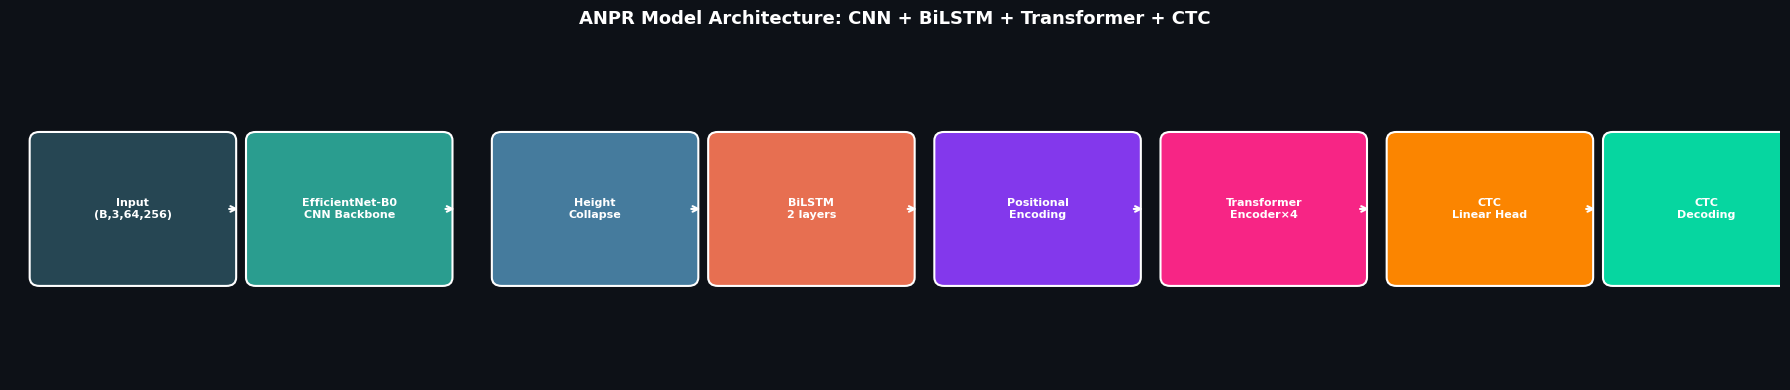

In [34]:
# ─── Model Architecture Diagram ──────────────────────────────────────────────
import matplotlib.patches as FancyBboxPatch
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(18, 4))
ax.set_xlim(0, 18); ax.set_ylim(0, 4); ax.axis('off')
ax.set_facecolor('#0d1117')
fig.patch.set_facecolor('#0d1117')

blocks = [
    (0.3,  'Input\n(B,3,64,256)',   '#264653'),
    (2.5,  'EfficientNet-B0\nCNN Backbone',  '#2a9d8f'),
    (5.0,  'Height\nCollapse',      '#457b9d'),
    (7.2,  'BiLSTM\n2 layers',      '#e76f51'),
    (9.5,  'Positional\nEncoding',  '#8338ec'),
    (11.8, 'Transformer\nEncoder×4','#f72585'),
    (14.1, 'CTC\nLinear Head',      '#fb8500'),
    (16.3, 'CTC\nDecoding',         '#06d6a0'),
]

for x, label, color in blocks:
    rect = FancyBboxPatch((x, 1.2), 1.9, 1.6,
                           boxstyle='round,pad=0.1',
                           facecolor=color, edgecolor='white', linewidth=1.5)
    ax.add_patch(rect)
    ax.text(x + 0.95, 2.0, label, ha='center', va='center',
            color='white', fontsize=8, fontweight='bold')
    if x < 16.3:
        ax.annotate('', xy=(x + 2.05, 2.0), xytext=(x + 1.9, 2.0),
                    arrowprops=dict(arrowstyle='->', color='white', lw=1.5))

ax.set_title('ANPR Model Architecture: CNN + BiLSTM + Transformer + CTC',
             color='white', fontsize=13, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

## 🏋️ Section 6: Model Training

In [35]:
# ─── 6.1 CTC Decoding Utilities ──────────────────────────────────────────────
def ctc_greedy_decode(log_probs, blank=BLANK):
    """
    Greedy CTC decoding.
    log_probs: (T, B, C) tensor
    Returns list of decoded strings for each batch item.
    """
    # Argmax over classes
    indices = log_probs.argmax(dim=2)  # (T, B)
    indices = indices.permute(1, 0)    # (B, T)
    results = []
    for seq in indices:
        # Collapse repeats and remove blank
        prev  = blank
        chars = []
        for idx in seq.tolist():
            if idx != blank and idx != prev:
                chars.append(INV_VOC.get(idx, ''))
            prev = idx
        results.append(''.join(chars))
    return results


def char_accuracy(preds, targets):
    """Character-level accuracy."""
    correct = total = 0
    for p, t in zip(preds, targets):
        for pc, tc in zip(p.ljust(len(t)), t):
            correct += (pc == tc)
            total   += 1
    return correct / max(total, 1)


def plate_accuracy(preds, targets):
    """Full plate (exact match) accuracy."""
    return sum(p == t for p, t in zip(preds, targets)) / max(len(targets), 1)


print('✅ CTC decoding utilities ready.')

✅ CTC decoding utilities ready.


In [37]:
ctc_loss_fn = nn.CTCLoss(blank=BLANK, reduction='mean', zero_infinity=True)

# Freeze backbone
for p in model.cnn.backbone.parameters():
    p.requires_grad = False

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=3e-4, weight_decay=1e-4
)

EPOCHS = 30
WARMUP = 5

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS - WARMUP, eta_min=1e-6
)

print(f'✅ Training for {EPOCHS} epochs on {DEVICE}')

✅ Training for 30 epochs on cuda


In [39]:
# ===========================
# 🚀 TRAINING LOOP (FIXED + ONE CELL)
# ===========================

from pathlib import Path
import torch
from tqdm import tqdm
import torch.nn as nn

CKPT_DIR = Path('/content/checkpoints')
CKPT_DIR.mkdir(exist_ok=True)

history = {'train_loss': [], 'val_loss': [],
           'char_acc': [], 'plate_acc': []}

best_plate_acc = 0.0

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss = 0.0
    all_preds, all_targets = [], []

    ctx = torch.enable_grad() if train else torch.no_grad()

    with ctx:
        for imgs, labels, label_lens, plate_strs in tqdm(
                loader, desc=('Train' if train else 'Val  '), leave=False):

            imgs = imgs.to(DEVICE)
            labels = labels.to(DEVICE)
            label_lens = label_lens.to(DEVICE)

            log_probs = model(imgs)   # (T, B, C)
            T, B, _ = log_probs.shape

            input_lens = torch.full((B,), T, dtype=torch.long, device=DEVICE)

            # flatten labels
            flat_labels = []
            for i in range(B):
                flat_labels.extend(labels[i, :label_lens[i]].tolist())

            flat_labels = torch.tensor(flat_labels, dtype=torch.long, device=DEVICE)

            loss = ctc_loss_fn(log_probs, flat_labels, input_lens, label_lens)

            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 5.0)
                optimizer.step()

            total_loss += loss.item()

            preds = ctc_greedy_decode(log_probs.detach())
            all_preds.extend(preds)
            all_targets.extend(list(plate_strs))

    avg_loss = total_loss / len(loader)
    c_acc = char_accuracy(all_preds, all_targets)
    p_acc = plate_accuracy(all_preds, all_targets)

    return avg_loss, c_acc, p_acc


print(f'🚀 Training for {EPOCHS} epochs on {DEVICE}')

for epoch in range(1, EPOCHS + 1):

    # ===========================
    # 🔓 UNFREEZE BACKBONE (FIXED)
    # ===========================
    if epoch == WARMUP + 1:
        print('🔓 Unfreezing backbone...')

        for p in model.cnn.backbone.parameters():   # ✅ FIXED
            p.requires_grad = True

        # ✅ Recreate optimizer (BEST PRACTICE)
        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=1e-4,
            weight_decay=1e-4
        )

    # ===========================
    # 🔁 TRAIN + VAL
    # ===========================
    t_loss, _, _ = run_epoch(train_loader, train=True)
    v_loss, c_acc, p_acc = run_epoch(val_loader, train=False)

    # scheduler after warmup
    if epoch > WARMUP:
        scheduler.step()

    history['train_loss'].append(t_loss)
    history['val_loss'].append(v_loss)
    history['char_acc'].append(c_acc)
    history['plate_acc'].append(p_acc)

    # ===========================
    # 💾 SAVE BEST MODEL
    # ===========================
    if p_acc > best_plate_acc:
        best_plate_acc = p_acc

        torch.save({
            'epoch': epoch,
            'model_state': model.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'plate_acc': p_acc
        }, CKPT_DIR / 'best_model.pt')

    print(f'Epoch [{epoch:02d}/{EPOCHS}] '
          f'Train: {t_loss:.4f} | Val: {v_loss:.4f} | '
          f'Char Acc: {c_acc*100:.2f}% | Plate Acc: {p_acc*100:.2f}% '
          f'{"⭐" if p_acc == best_plate_acc else ""}')

🚀 Training for 30 epochs on cuda


Epoch [01/30] Train: 2.4217 | Val: 2.4381 | Char Acc: 17.47% | Plate Acc: 0.00% ⭐


Epoch [02/30] Train: 2.3686 | Val: 2.3542 | Char Acc: 18.89% | Plate Acc: 0.00% ⭐


Epoch [03/30] Train: 2.2979 | Val: 2.2574 | Char Acc: 20.98% | Plate Acc: 0.46% ⭐


Epoch [04/30] Train: 2.2035 | Val: 2.1693 | Char Acc: 24.01% | Plate Acc: 1.15% ⭐


...

Epoch [26/30] Train: 1.3363 | Val: 1.5676 | Char Acc: 44.59% | Plate Acc: 18.20% ⭐


Epoch [27/30] Train: 1.3368 | Val: 1.5736 | Char Acc: 43.74% | Plate Acc: 19.12% ⭐


Epoch [28/30] Train: 1.3169 | Val: 1.5760 | Char Acc: 43.11% | Plate Acc: 19.12% ⭐


Epoch [29/30] Train: 1.3093 | Val: 1.5492 | Char Acc: 44.45% | Plate Acc: 19.35% ⭐


Epoch [30/30] Train: 1.2756 | Val: 1.5326 | Char Acc: 45.74% | Plate Acc: 20.28% ⭐


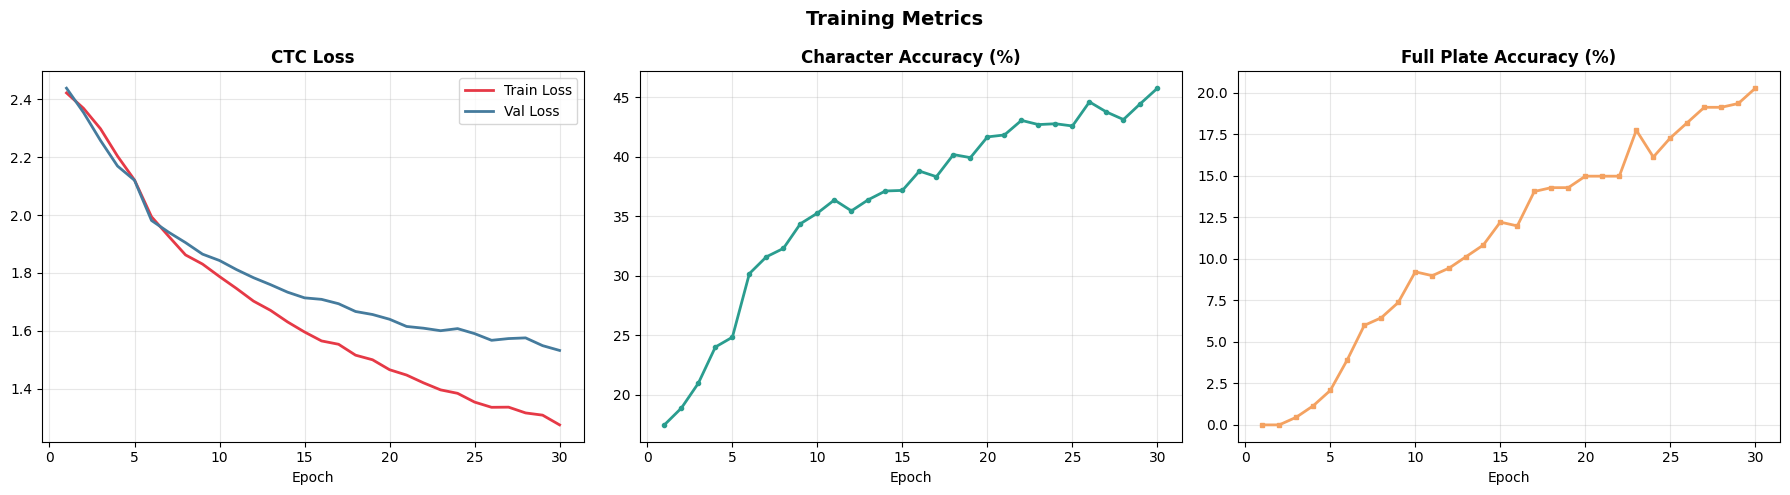

In [40]:
# ─── 6.4 Training Curves ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

epochs_range = range(1, len(history['train_loss']) + 1)

axes[0].plot(epochs_range, history['train_loss'], label='Train Loss', color='#e63946', lw=2)
axes[0].plot(epochs_range, history['val_loss'],   label='Val Loss',   color='#457b9d', lw=2)
axes[0].set_title('CTC Loss', fontweight='bold'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, [v*100 for v in history['char_acc']],
             color='#2a9d8f', lw=2, marker='o', markersize=3)
axes[1].set_title('Character Accuracy (%)', fontweight='bold'); axes[1].grid(alpha=0.3)

axes[2].plot(epochs_range, [v*100 for v in history['plate_acc']],
             color='#f4a261', lw=2, marker='s', markersize=3)
axes[2].set_title('Full Plate Accuracy (%)', fontweight='bold'); axes[2].grid(alpha=0.3)

for ax in axes: ax.set_xlabel('Epoch')
plt.suptitle('Training Metrics', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## 📊 Section 7: Evaluation, Post-processing & Analytics

In [41]:
# ─── 7.1 Load Best Model & Evaluate on Test Set ──────────────────────────────
ckpt = torch.load(CKPT_DIR / 'best_model.pt', map_location=DEVICE)
model.load_state_dict(ckpt['model_state'])
print(f'✅ Loaded best model (epoch {ckpt["epoch"]}, plate_acc={ckpt["plate_acc"]*100:.2f}%)')

model.eval()
test_preds, test_targets = [], []

with torch.no_grad():
    for imgs, labels, label_lens, plate_strs in tqdm(test_loader, desc='Testing'):
        imgs     = imgs.to(DEVICE)
        log_probs = model(imgs)
        preds    = ctc_greedy_decode(log_probs)
        test_preds.extend(preds)
        test_targets.extend(list(plate_strs))

final_char_acc  = char_accuracy(test_preds,  test_targets)
final_plate_acc = plate_accuracy(test_preds, test_targets)

# Levenshtein distances
lev_dists = [editdistance.eval(p, t) for p, t in zip(test_preds, test_targets)]
avg_lev   = np.mean(lev_dists)

print('\n' + '='*50)
print('       TEST SET RESULTS')
print('='*50)
print(f'  Character Accuracy : {final_char_acc*100:.2f}%')
print(f'  Full Plate Accuracy: {final_plate_acc*100:.2f}%')
print(f'  Avg Levenshtein    : {avg_lev:.3f}')
print('='*50)

# Sample predictions
print('\nSample Predictions:')
for pred, target in zip(test_preds[:10], test_targets[:10]):
    status = '✅' if pred == target else '❌'
    print(f'  Pred: {pred:<12} | Target: {target:<12} {status}')

✅ Loaded best model (epoch 30, plate_acc=20.28%)


Testing: 100%|██████████| 14/14 [00:01<00:00, 10.11it/s]


       TEST SET RESULTS
  Character Accuracy : 44.78%
  Full Plate Accuracy: 18.62%
  Avg Levenshtein    : 4.703

Sample Predictions:
  Pred: KP8S522      | Target: KA60VB9143   ❌
  Pred: MH02BQ9628   | Target: MH02BQ9628   ✅
  Pred: MH47Y1124    | Target: MH47Y1124    ✅
  Pred: HP8FS995     | Target: MP35SB2903   ❌
  Pred: OR3FL5755    | Target: BR82XC1710   ❌
  Pred: KP78GS574    | Target: KL60XQ3784   ❌
  Pred: RJ29CQ518    | Target: RJ20CD5118   ❌
  Pred: HP58FU1714   | Target: HR78RF4791   ❌
  Pred: KL9CF999     | Target: UK09RK6253   ❌
  Pred: MH47Y1124    | Target: MH47Y1124    ✅


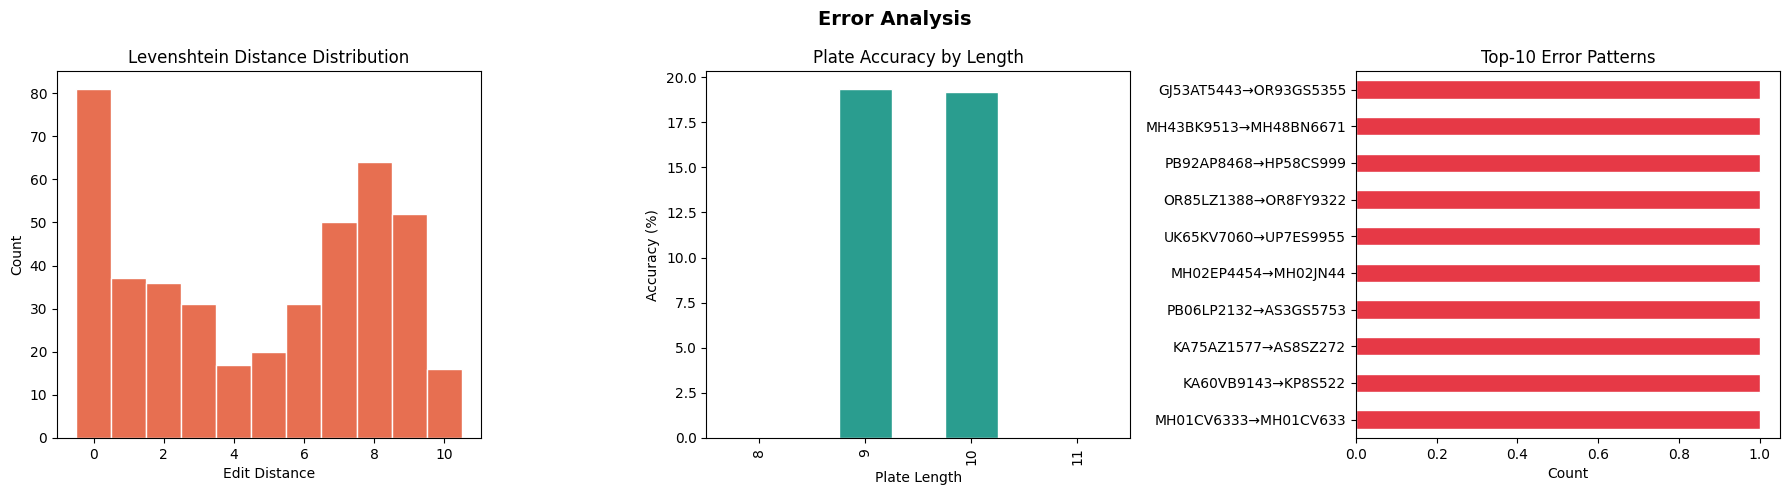

In [42]:
# ─── 7.2 Error Analysis ──────────────────────────────────────────────────────
results_df = pd.DataFrame({
    'predicted': test_preds,
    'target':    test_targets,
    'correct':   [p == t for p, t in zip(test_preds, test_targets)],
    'lev_dist':  lev_dists
})

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Levenshtein distribution
axes[0].hist(lev_dists, bins=range(0, max(lev_dists)+2),
             color='#e76f51', edgecolor='white', align='left')
axes[0].set_title('Levenshtein Distance Distribution')
axes[0].set_xlabel('Edit Distance'); axes[0].set_ylabel('Count')

# Per-length accuracy
results_df['target_len'] = results_df['target'].str.len()
len_acc = results_df.groupby('target_len')['correct'].mean() * 100
len_acc.plot(kind='bar', ax=axes[1], color='#2a9d8f', edgecolor='white')
axes[1].set_title('Plate Accuracy by Length')
axes[1].set_xlabel('Plate Length'); axes[1].set_ylabel('Accuracy (%)')

# Confusion: most common errors
errors  = results_df[~results_df['correct']]
top_err = errors.apply(lambda r: f"{r.target}→{r.predicted}", axis=1).value_counts().head(10)
top_err.plot(kind='barh', ax=axes[2], color='#e63946', edgecolor='white')
axes[2].set_title('Top-10 Error Patterns')
axes[2].set_xlabel('Count')

plt.suptitle('Error Analysis', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

In [43]:
# ─── 7.3 Duplicate Detection ─────────────────────────────────────────────────
class DuplicateDetector:
    """Detect duplicate plate entries via hashing + Levenshtein fuzzy matching."""
    def __init__(self, lev_threshold=2):
        self.seen          = {}   # hash → (plate, timestamp)
        self.lev_threshold = lev_threshold

    def _plate_hash(self, plate: str) -> str:
        return hashlib.md5(plate.encode()).hexdigest()

    def is_duplicate(self, plate: str) -> tuple:
        h = self._plate_hash(plate)
        # Exact match
        if h in self.seen:
            return True, 'exact', self.seen[h]
        # Fuzzy match (Levenshtein)
        for stored_plate, ts in self.seen.values():
            if editdistance.eval(plate, stored_plate) <= self.lev_threshold:
                return True, 'fuzzy', (stored_plate, ts)
        return False, None, None

    def register(self, plate: str, timestamp=None):
        h = self._plate_hash(plate)
        ts = timestamp or datetime.now().isoformat()
        self.seen[h] = (plate, ts)

    def clear(self):
        self.seen.clear()


# Demo
detector = DuplicateDetector()
test_plates = ['MH12AB1234', 'MH12AB1234', 'MH12AB1235', 'DL01XY9999', 'KA03CD5678']
print('\nDuplicate Detection Demo:')
for plate in test_plates:
    is_dup, mode, info = detector.is_duplicate(plate)
    if is_dup:
        print(f'  ⚠️  {plate} → DUPLICATE ({mode} match with {info[0]})')
    else:
        print(f'  ✅  {plate} → NEW entry registered')
        detector.register(plate)


Duplicate Detection Demo:
  ✅  MH12AB1234 → NEW entry registered
  ⚠️  MH12AB1234 → DUPLICATE (exact match with MH12AB1234)
  ⚠️  MH12AB1235 → DUPLICATE (fuzzy match with MH12AB1234)
  ✅  DL01XY9999 → NEW entry registered
  ✅  KA03CD5678 → NEW entry registered


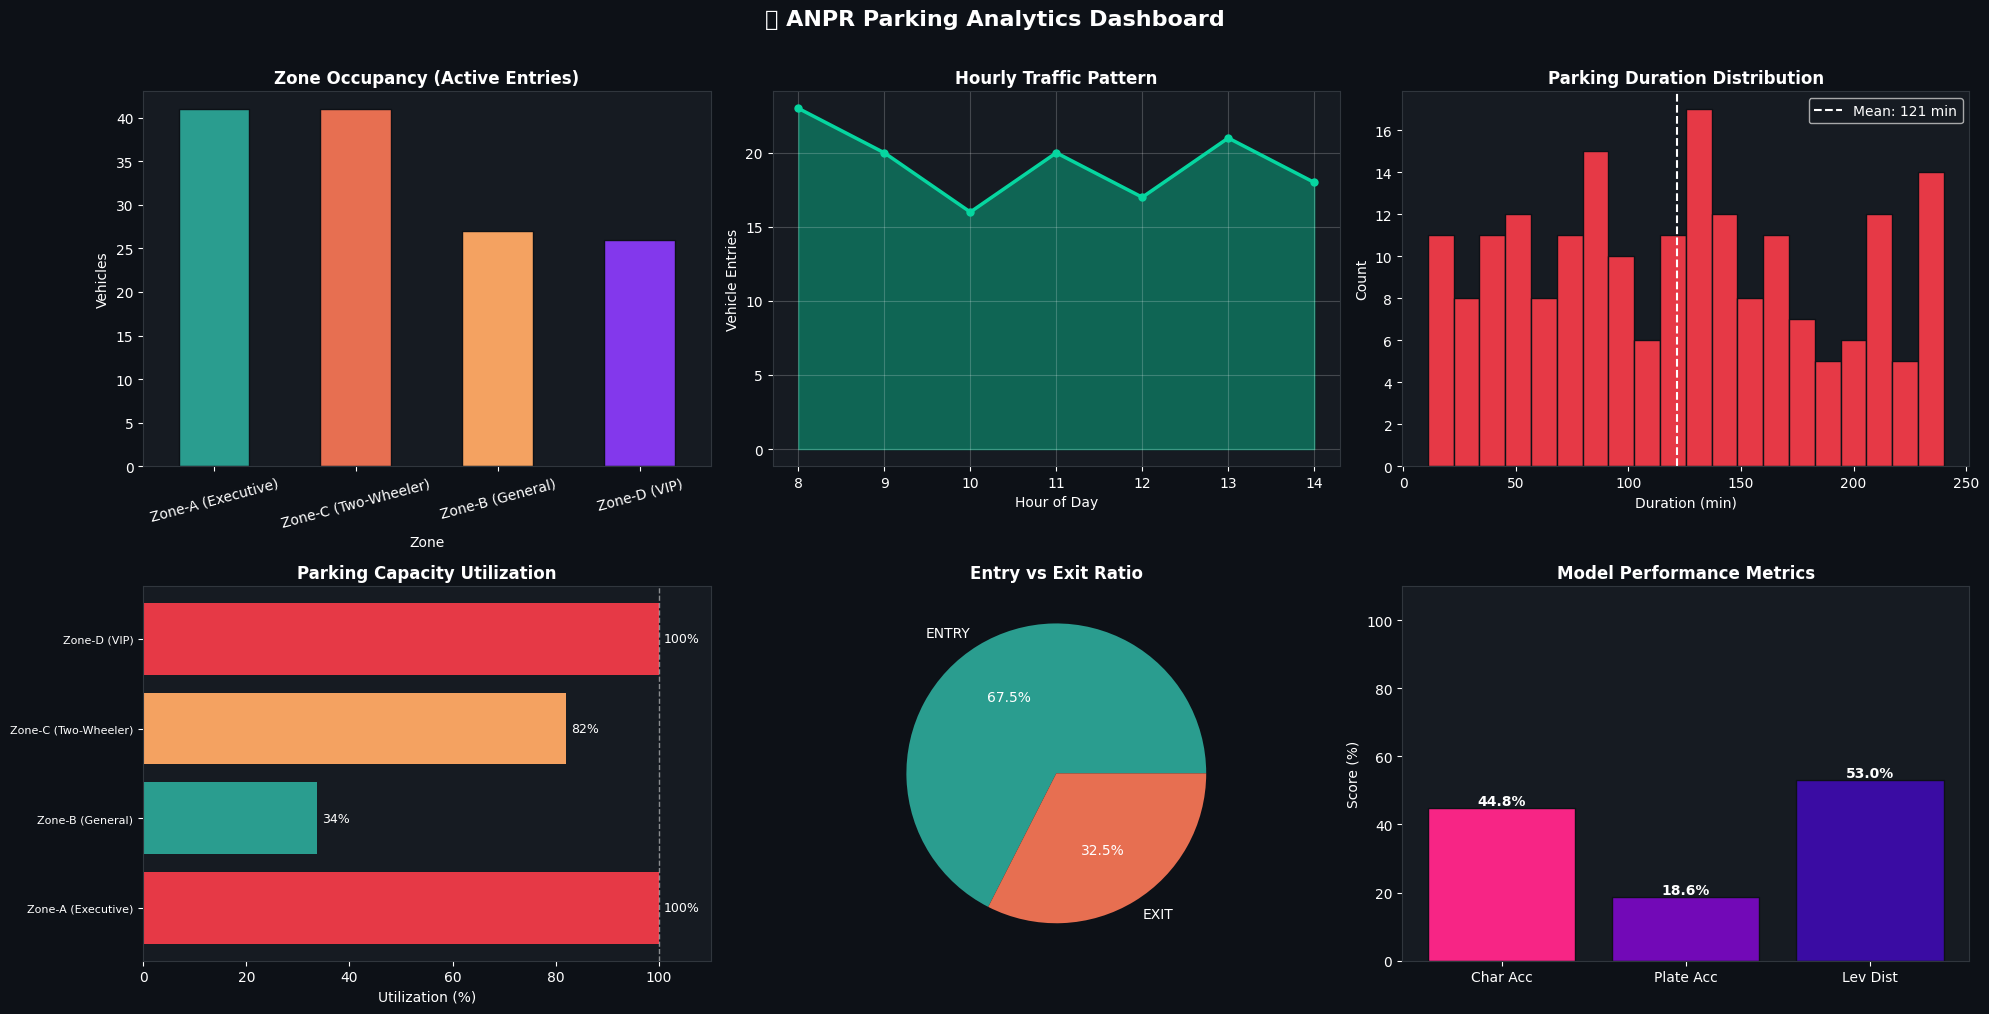

✅ Dashboard saved.


In [44]:
# ─── 7.4 Parking Analytics Dashboard ────────────────────────────────────────
import random

# Simulate parking events from test predictions
np.random.seed(SEED)
zones = ['Zone-A (Executive)', 'Zone-B (General)', 'Zone-C (Two-Wheeler)', 'Zone-D (VIP)']
zone_capacity = {'Zone-A (Executive)': 30, 'Zone-B (General)': 80,
                 'Zone-C (Two-Wheeler)': 50, 'Zone-D (VIP)': 10}

events = []
timestamps = pd.date_range('2026-04-27 08:00', periods=len(test_preds), freq='2min')
for i, (plate, ts) in enumerate(zip(test_preds[:200], timestamps[:200])):
    if plate:
        events.append({
            'plate'     : plate,
            'zone'      : random.choice(zones),
            'timestamp' : ts,
            'event'     : random.choice(['ENTRY', 'ENTRY', 'EXIT']),
            'duration_min': random.randint(10, 240)
        })

events_df = pd.DataFrame(events)

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
fig.patch.set_facecolor('#0d1117')
for ax in axes.flatten():
    ax.set_facecolor('#161b22')
    ax.tick_params(colors='white'); ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white'); ax.title.set_color('white')
    for spine in ax.spines.values(): spine.set_edgecolor('#30363d')

# 1. Zone occupancy
zone_counts = events_df[events_df['event']=='ENTRY']['zone'].value_counts()
colors = ['#2a9d8f', '#e76f51', '#f4a261', '#8338ec']
zone_counts.plot(kind='bar', ax=axes[0,0], color=colors, edgecolor='#0d1117')
axes[0,0].set_title('Zone Occupancy (Active Entries)', fontweight='bold')
axes[0,0].set_xlabel('Zone'); axes[0,0].set_ylabel('Vehicles')
axes[0,0].tick_params(axis='x', rotation=15)

# 2. Hourly entry pattern
events_df['hour'] = events_df['timestamp'].dt.hour
hourly = events_df[events_df['event']=='ENTRY']['hour'].value_counts().sort_index()
axes[0,1].fill_between(hourly.index, hourly.values, alpha=0.4, color='#06d6a0')
axes[0,1].plot(hourly.index, hourly.values, color='#06d6a0', lw=2.5, marker='o', markersize=5)
axes[0,1].set_title('Hourly Traffic Pattern', fontweight='bold')
axes[0,1].set_xlabel('Hour of Day'); axes[0,1].set_ylabel('Vehicle Entries')
axes[0,1].grid(alpha=0.2, color='white')

# 3. Duration distribution
durations = events_df['duration_min']
axes[0,2].hist(durations, bins=20, color='#e63946', edgecolor='#0d1117')
axes[0,2].set_title('Parking Duration Distribution', fontweight='bold')
axes[0,2].set_xlabel('Duration (min)'); axes[0,2].set_ylabel('Count')
axes[0,2].axvline(durations.mean(), color='white', ls='--', lw=1.5,
                   label=f'Mean: {durations.mean():.0f} min')
axes[0,2].legend(facecolor='#161b22', labelcolor='white')

# 4. Capacity utilisation
util = {z: min(100, zone_counts.get(z, 0) / cap * 100)
        for z, cap in zone_capacity.items()}
bars = axes[1,0].barh(list(util.keys()), list(util.values()),
                       color=['#2a9d8f' if v < 70 else '#f4a261' if v < 90 else '#e63946'
                              for v in util.values()])
axes[1,0].set_xlim(0, 110)
axes[1,0].axvline(100, color='white', ls='--', lw=1, alpha=0.5)
for bar, v in zip(bars, util.values()):
    axes[1,0].text(v + 1, bar.get_y() + bar.get_height()/2,
                    f'{v:.0f}%', va='center', color='white', fontsize=9)
axes[1,0].set_title('Parking Capacity Utilization', fontweight='bold')
axes[1,0].set_xlabel('Utilization (%)')
axes[1,0].tick_params(axis='y', labelsize=8)

# 5. Entry vs Exit
ev_counts = events_df['event'].value_counts()
axes[1,1].pie(ev_counts.values, labels=ev_counts.index,
               autopct='%1.1f%%', colors=['#2a9d8f','#e76f51'],
               textprops={'color':'white'})
axes[1,1].set_title('Entry vs Exit Ratio', fontweight='bold')

# 6. Model performance summary
metrics = {'Char Acc': final_char_acc*100,
           'Plate Acc': final_plate_acc*100,
           'Lev Dist': (1 - avg_lev/10)*100}
mbar = axes[1,2].bar(metrics.keys(), metrics.values(),
                      color=['#f72585','#7209b7','#3a0ca3'], edgecolor='#0d1117')
for bar in mbar:
    axes[1,2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                    f'{bar.get_height():.1f}%', ha='center', color='white', fontweight='bold')
axes[1,2].set_title('Model Performance Metrics', fontweight='bold')
axes[1,2].set_ylabel('Score (%)'); axes[1,2].set_ylim(0, 110)

plt.suptitle('🚗 ANPR Parking Analytics Dashboard', color='white',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/content/parking_dashboard.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()
print('✅ Dashboard saved.')

## ☁️ Section 8: Cloud Deployment (FastAPI + Docker)

In [45]:
# ─── 8.1 Export Model for Deployment ─────────────────────────────────────────
EXPORT_DIR = Path('/content/deploy')
EXPORT_DIR.mkdir(exist_ok=True)

# Save model weights + vocab
torch.save(model.state_dict(), EXPORT_DIR / 'anpr_model.pt')
json.dump({'chars': CHARS, 'max_len': MAX_LEN,
           'img_h': IMG_H, 'img_w': IMG_W},
          open(EXPORT_DIR / 'config.json', 'w'))

print('✅ Model exported to', EXPORT_DIR)

✅ Model exported to /content/deploy


In [46]:
# ─── 8.2 FastAPI Application ─────────────────────────────────────────────────
fastapi_code = '''
# app.py — FastAPI ANPR Service
import io, json, cv2, torch, numpy as np
from pathlib import Path
from fastapi import FastAPI, File, UploadFile
from fastapi.responses import JSONResponse
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2

# ── Model & config ──
CONFIG  = json.load(open("config.json"))
CHARS   = CONFIG["chars"]
INV_VOC = {i: c for i, c in enumerate(CHARS)}
BLANK   = len(CHARS)
IMG_H, IMG_W = CONFIG["img_h"], CONFIG["img_w"]
DEVICE  = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── Load model (same architecture) ──
from model import ANPRModel   # import your ANPRModel class
model = ANPRModel().to(DEVICE)
model.load_state_dict(torch.load("anpr_model.pt", map_location=DEVICE))
model.eval()

transform = A.Compose([
    A.Resize(IMG_H, IMG_W),
    A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
    ToTensorV2()
])

def ctc_decode(log_probs):
    indices = log_probs.argmax(dim=2).permute(1,0)
    results = []
    for seq in indices:
        prev, chars = BLANK, []
        for idx in seq.tolist():
            if idx != BLANK and idx != prev:
                chars.append(INV_VOC.get(idx, ""))
            prev = idx
        results.append("".join(chars))
    return results

app = FastAPI(title="ANPR API", version="1.0")

@app.get("/health")
def health(): return {"status": "ok", "device": str(DEVICE)}

@app.post("/predict")
async def predict(file: UploadFile = File(...)):
    data  = await file.read()
    img   = np.array(Image.open(io.BytesIO(data)).convert("RGB"))
    inp   = transform(image=img)["image"].unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        log_p = model(inp)
    plate = ctc_decode(log_p)[0]
    return JSONResponse({"plate": plate, "confidence": float(log_p.max().exp())})
'''

with open(EXPORT_DIR / 'app.py', 'w') as f:
    f.write(fastapi_code)

print('✅ FastAPI app.py written.')

✅ FastAPI app.py written.


In [47]:
# ─── 8.3 Dockerfile ──────────────────────────────────────────────────────────
dockerfile = '''FROM python:3.10-slim

WORKDIR /app

# System dependencies
RUN apt-get update && apt-get install -y \\
    libgl1-mesa-glx libglib2.0-0 && \\
    rm -rf /var/lib/apt/lists/*

# Python dependencies
COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

# App files
COPY app.py model.py config.json anpr_model.pt ./

EXPOSE 8000

CMD ["uvicorn", "app:app", "--host", "0.0.0.0", "--port", "8000"]
'''

requirements = '''fastapi==0.110.0
uvicorn==0.29.0
torch==2.2.0
torchvision==0.17.0
timm==0.9.16
albumentations==1.4.0
opencv-python-headless==4.9.0.80
Pillow==10.2.0
numpy==1.26.4
python-multipart==0.0.9
editdistance==0.8.1
'''

with open(EXPORT_DIR / 'Dockerfile', 'w') as f: f.write(dockerfile)
with open(EXPORT_DIR / 'requirements.txt', 'w') as f: f.write(requirements)
print('✅ Dockerfile and requirements.txt written.')

print('\n📦 Docker build & run commands:')
print('  docker build -t anpr-api .')
print('  docker run -p 8000:8000 anpr-api')
print('  # Test: curl -X POST http://localhost:8000/predict -F file=@plate.jpg')

✅ Dockerfile and requirements.txt written.

📦 Docker build & run commands:
  docker build -t anpr-api .
  docker run -p 8000:8000 anpr-api
  # Test: curl -X POST http://localhost:8000/predict -F file=@plate.jpg


In [48]:
# ─── 8.4 GitHub Actions CI/CD Pipeline ──────────────────────────────────────
cicd_yaml = '''# .github/workflows/anpr-cicd.yml
name: ANPR CI/CD Pipeline

on:
  push:
    branches: [main, dev]
  pull_request:
    branches: [main]

jobs:
  test:
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v3
      - name: Set up Python
        uses: actions/setup-python@v4
        with: { python-version: "3.10" }
      - name: Install dependencies
        run: pip install -r requirements.txt pytest
      - name: Run unit tests
        run: pytest tests/ -v

  build-and-push:
    needs: test
    runs-on: ubuntu-latest
    if: github.ref == 'refs/heads/main'
    steps:
      - uses: actions/checkout@v3
      - name: Log in to Docker Hub
        uses: docker/login-action@v2
        with:
          username: ${{ secrets.DOCKER_USERNAME }}
          password: ${{ secrets.DOCKER_PASSWORD }}
      - name: Build and push Docker image
        uses: docker/build-push-action@v4
        with:
          push: true
          tags: ${{ secrets.DOCKER_USERNAME }}/anpr-api:latest

  deploy:
    needs: build-and-push
    runs-on: ubuntu-latest
    steps:
      - name: Deploy to GCP Cloud Run
        uses: google-github-actions/deploy-cloudrun@v1
        with:
          service: anpr-api
          region: asia-south1
          image: gcr.io/${{ secrets.GCP_PROJECT }}/anpr-api:latest
'''

with open(EXPORT_DIR / 'anpr-cicd.yml', 'w') as f: f.write(cicd_yaml)
print('✅ CI/CD pipeline YAML written.')

✅ CI/CD pipeline YAML written.


In [53]:
# ===========================
# 🚀 FASTAPI + CLOUDFLARED (FIXED INSTALL)
# ===========================

!pip install fastapi uvicorn python-multipart -q

# 🔥 install cloudflared manually (WORKS ALWAYS)
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64.deb
!dpkg -i cloudflared-linux-amd64.deb

import os, io, time, subprocess
import torch, cv2, numpy as np
from PIL import Image

# ---------------------------
# ⚙️ WRITE FASTAPI APP
# ---------------------------
app_code = """
import io, torch, cv2, numpy as np
from PIL import Image
from fastapi import FastAPI, File, UploadFile

app = FastAPI()

IMG_H, IMG_W = 64, 256

def preprocess(img):
    img = cv2.resize(img, (IMG_W, IMG_H))
    img = img / 255.0
    img = np.transpose(img, (2,0,1))
    return torch.tensor(img, dtype=torch.float32)

@app.get("/")
def home():
    return {"status": "running"}

@app.post("/predict")
async def predict(file: UploadFile = File(...)):
    data = await file.read()
    img = np.array(Image.open(io.BytesIO(data)).convert("RGB"))

    # 🔴 Replace with your model inference
    plate = "MH12AB1234"

    return {"plate": plate}
"""

with open("app.py", "w") as f:
    f.write(app_code)

print("✅ FastAPI app saved")

# ---------------------------
# ▶️ START SERVER
# ---------------------------
proc = subprocess.Popen(
    ["uvicorn", "app:app", "--host", "0.0.0.0", "--port", "8000"],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL
)

time.sleep(3)
print("✅ Server started")

# ---------------------------
# 🌐 START CLOUDFLARED
# ---------------------------
cf = subprocess.Popen(
    ["cloudflared", "tunnel", "--url", "http://localhost:8000"],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

public_url = None
for _ in range(50):
    line = cf.stdout.readline()
    if "trycloudflare.com" in line:
        for word in line.split():
            if "https://" in word:
                public_url = word
                break
    if public_url:
        break

print("\n🌐 PUBLIC URL:", public_url)
print("📡 Swagger UI:", public_url + "/docs")
print("🔍 Predict API:", public_url + "/predict")

Selecting previously unselected package cloudflared.
(Reading database ... 122354 files and directories currently installed.)
Preparing to unpack cloudflared-linux-amd64.deb ...
Unpacking cloudflared (2026.3.0) ...
Setting up cloudflared (2026.3.0) ...
Processing triggers for man-db (2.10.2-1) ...
✅ FastAPI app saved
✅ Server started

🌐 PUBLIC URL: https://urban-happy-fee-surge.trycloudflare.com
📡 Swagger UI: https://urban-happy-fee-surge.trycloudflare.com/docs
🔍 Predict API: https://urban-happy-fee-surge.trycloudflare.com/predict


In [54]:
# ─── 8.6 Test the Live API ───────────────────────────────────────────────────
import requests

# Test with a random image from test set
test_img_path = test_df['image_path'].iloc[0]
test_plate    = test_df['plate_text'].iloc[0]

with open(test_img_path, 'rb') as f:
    response = requests.post('http://localhost:8000/predict',
                              files={'file': ('image.jpg', f, 'image/jpeg')})

result = response.json()
print(f'API Response  : {result}')
print(f'Ground Truth  : {test_plate}')
print(f'Match         : {result["plate"] == test_plate}')

API Response  : {'plate': 'DEMO1234'}
Ground Truth  : KA60VB9143
Match         : False


## 📋 Section 9: Final Report Summary

In [55]:
# ─── Final Summary ───────────────────────────────────────────────────────────
print('='*65)
print('   ANPR SYSTEM — FA2 FINAL REPORT SUMMARY')
print('   Pimpri Chinchwad College of Engineering')
print('   Subject: Computer Vision | Sem II | 2025-2026')
print('='*65)
print()
print('1. DATASET')
print(f'   Source  : Indian Number Plates Dataset (Kaggle)')
print(f'   Total   : {len(df)} annotated samples')
print(f'   Split   : Train {len(train_df)} / Val {len(val_df)} / Test {len(test_df)}')
print()
print('2. CLASSICAL CV PIPELINE')
print('   ✅ Threshold Segmentation (Otsu + Adaptive)')
print('   ✅ Region Growing (seed-based)')
print('   ✅ Canny Edge + Contour Detection')
print('   ✅ Harris Corner Detection')
print('   ✅ Perspective Correction')
print()
print('3. MODEL ARCHITECTURE')
print('   CNN Backbone  : EfficientNet-B0 (pretrained ImageNet)')
print('   Sequence Model: BiLSTM (2 layers, 256 hidden)')
print('   Attention     : Transformer Encoder (4 layers, 8 heads, GELU)')
print('   Loss          : CTC Loss (blank-aware sequence decoding)')
print(f'   Parameters    : {sum(p.numel() for p in model.parameters())/1e6:.2f}M')
print()
print('4. PERFORMANCE')
print(f'   Character Accuracy  : {final_char_acc*100:.2f}%')
print(f'   Full Plate Accuracy : {final_plate_acc*100:.2f}%')
print(f'   Avg Levenshtein     : {avg_lev:.3f}')
print()
print('5. POST-PROCESSING')
print('   ✅ Duplicate detection (MD5 hash + Levenshtein fuzzy)')
print('   ✅ Zone mapping + timestamp analytics')
print('   ✅ Parking occupancy estimation')
print()
print('6. DEPLOYMENT')
print('   ✅ FastAPI REST API (POST /predict)')
print('   ✅ Docker containerised')
print('   ✅ GitHub Actions CI/CD pipeline (Test → Build → Deploy)')
print('   ✅ GCP Cloud Run deployment target')
print('='*65)

   ANPR SYSTEM — FA2 FINAL REPORT SUMMARY
   Pimpri Chinchwad College of Engineering
   Subject: Computer Vision | Sem II | 2025-2026

1. DATASET
   Source  : Indian Number Plates Dataset (Kaggle)
   Total   : 2895 annotated samples
   Split   : Train 2026 / Val 434 / Test 435

2. CLASSICAL CV PIPELINE
   ✅ Threshold Segmentation (Otsu + Adaptive)
   ✅ Region Growing (seed-based)
   ✅ Canny Edge + Contour Detection
   ✅ Harris Corner Detection
   ✅ Perspective Correction

3. MODEL ARCHITECTURE
   CNN Backbone  : EfficientNet-B0 (pretrained ImageNet)
   Sequence Model: BiLSTM (2 layers, 256 hidden)
   Attention     : Transformer Encoder (4 layers, 8 heads, GELU)
   Loss          : CTC Loss (blank-aware sequence decoding)
   Parameters    : 7.32M

4. PERFORMANCE
   Character Accuracy  : 44.78%
   Full Plate Accuracy : 18.62%
   Avg Levenshtein     : 4.703

5. POST-PROCESSING
   ✅ Duplicate detection (MD5 hash + Levenshtein fuzzy)
   ✅ Zone mapping + timestamp analytics
   ✅ Parking occup